In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import os

In [2]:
files = os.listdir()
files = [file for file in files if 'txt' in file]
files

['OX359249.1.4D_pi.gt_counts.txt',
 'OX359249.1.0D_pi.gt_counts.txt',
 'OX359245.1.4D_pi.gt_counts.txt',
 'OX359247.1.0D_pi.gt_counts.txt',
 'OX359247.1.4D_pi.gt_counts.txt',
 'OX359245.1.0D_pi.gt_counts.txt',
 'OX359248.1.4D_pi.gt_counts.txt',
 'OX359248.1.0D_pi.gt_counts.txt',
 'OX359250.1.0D_pi.gt_counts.txt',
 'OX359246.1.0D_pi.gt_counts.txt',
 'OX359250.1.4D_pi.gt_counts.txt',
 'OX359246.1.4D_pi.gt_counts.txt']

In [3]:
df_list = []
for file in files:
    chromosome = file.split('.')[0]
    degen = file.split('.')[2].split('_')[0]
    df = pd.read_csv(file, sep = '\t')
    df['chromosome'] = chromosome
    df['degen'] = degen
    df_list.append(df)
df = pd.concat(df_list)

In [7]:
df_list[0]

,hom_ref,het,hom_alt,chromosome,degen
0,75732.0,56324.0,22640.0,OX359249,4D
1,77032.0,53829.0,23855.0,OX359249,4D
2,75172.0,54533.0,24990.0,OX359249,4D
3,75699.0,56095.0,22895.0,OX359249,4D
4,76576.0,54232.0,23865.0,OX359249,4D
5,75438.0,55412.0,23842.0,OX359249,4D
6,73966.0,56574.0,24157.0,OX359249,4D
7,79887.0,51245.0,23558.0,OX359249,4D
8,74139.0,55199.0,25366.0,OX359249,4D
9,76484.0,54189.0,24028.0,OX359249,4D


In [4]:
df['gt_tot'] = df[['hom_ref','het','hom_alt']].sum(axis=1)
df['hom_ref_prop'] = df['hom_ref']/df['gt_tot']
df['het_prop'] = df['het']/df['gt_tot']
df['hom_alt_prop'] = df['hom_alt']/df['gt_tot']
df['LG'] = df['chromosome'] + ' ' + df['degen']
ZD_LG_list = [lg for lg in df['LG'].unique() if '0D' in lg]
FD_LG_list = [lg for lg in df['LG'].unique() if '4D' in lg]

In [5]:
prop_df = df[['hom_ref_prop','het_prop','hom_alt_prop', 'LG']]
prop_df.set_index('LG', inplace=True)
prop_df

,hom_ref_prop,het_prop,hom_alt_prop
LG,,,
OX359249 4D,0.489554,0.364095,0.146352
OX359249 4D,0.497893,0.347921,0.154186
OX359249 4D,0.485937,0.352519,0.161544
OX359249 4D,0.489363,0.362631,0.148007
OX359249 4D,0.495083,0.350624,0.154293
...,...,...,...
OX359246 4D,0.555988,0.303345,0.140667
OX359246 4D,0.542773,0.307658,0.149569
OX359246 4D,0.574949,0.292517,0.132534


In [195]:
prop_df.loc['OX359249 0D']

,hom_ref_prop,het_prop,hom_alt_prop
LG,,,
OX359249 0D,0.489554,0.364095,0.146352
OX359249 0D,0.497893,0.347921,0.154186
OX359249 0D,0.485937,0.352519,0.161544
OX359249 0D,0.489363,0.362631,0.148007
OX359249 0D,0.495083,0.350624,0.154293
OX359249 0D,0.487666,0.358209,0.154126
OX359249 0D,0.478135,0.365708,0.156157
OX359249 0D,0.516433,0.331275,0.152292
OX359249 0D,0.479231,0.356804,0.163965


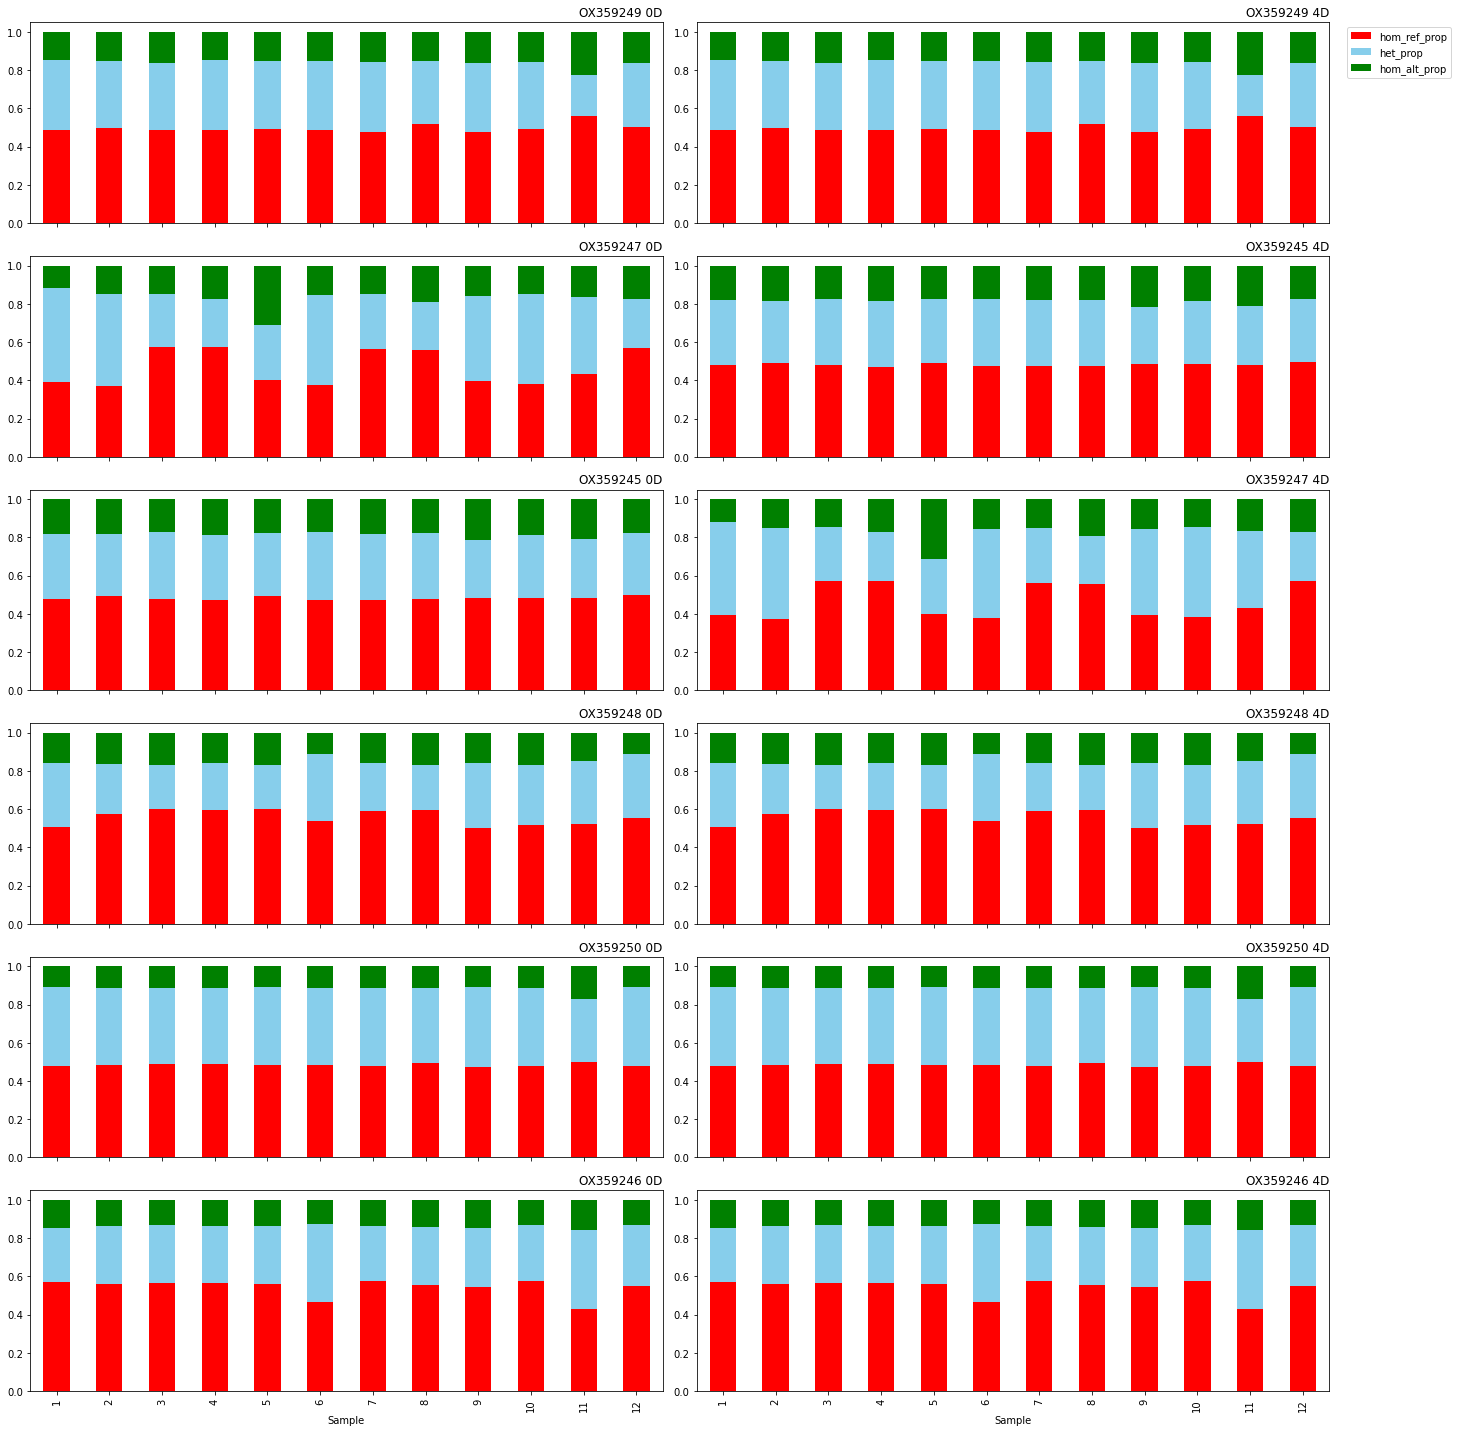

In [196]:
fig, axs = plt.subplots(nrows = len(ZD_LG_list), ncols=2, figsize=[20,20], sharex=True)

for i, lgs in enumerate(zip(ZD_LG_list, FD_LG_list)):
    ZD, FD = lgs
    ZD_ax = axs[i,0]
    FD_ax = axs[i,1]
    ZD_df = prop_df.loc[ZD]
    FD_df = prop_df.loc[FD]
    
    ZD_df.plot(kind='bar', stacked=True, color=['red', 'skyblue', 'green'], ax=ZD_ax)
    FD_df.plot(kind='bar', stacked=True, color=['red', 'skyblue', 'green'], ax=FD_ax)
    
    xlabs = [i+1 for i in range(len(ZD_df))]
    ZD_ax.set_xticklabels(xlabs)
    FD_ax.set_xticklabels(xlabs)
    
    ZD_ax.set_xlabel('Sample')
    FD_ax.set_xlabel('Sample')
    
    ZD_ax.set_title(ZD, loc='right')
    FD_ax.set_title(FD, loc='right')
    
    ZD_ax.get_legend().remove()
    FD_ax.legend(bbox_to_anchor=(0.7, 0.5, 0.5, 0.5))
    if i > 0:
        FD_ax.get_legend().remove()
    
plt.tight_layout()

In [181]:
df.groupby('LG')[['hom_ref_prop','het_prop','hom_alt_prop']].mean()

,hom_ref_prop,het_prop,hom_alt_prop
LG,,,
OX359245 0D,0.481664,0.333295,0.185040
OX359245 4D,0.481664,0.333295,0.185040
OX359246 0D,0.542728,0.318558,0.138714
OX359246 4D,0.542728,0.318558,0.138714
OX359247 0D,0.465422,0.364405,0.170173
OX359247 4D,0.465422,0.364405,0.170173
OX359248 0D,0.558163,0.288580,0.153258
OX359248 4D,0.558163,0.288580,0.153258
OX359249 0D,0.498190,0.340638,0.161172


In [182]:
files = os.listdir('./fiftons')
files = [file for file in files if 'txt' in file]
files = ['./fiftons/' + file for file in files]
files

['./fiftons/OX359247.1.0D_pi.fifton_gc.txt',
 './fiftons/OX359245.1.4D_pi.fifton_gc.txt',
 './fiftons/OX359245.1.0D_pi.fifton_gc.txt',
 './fiftons/OX359247.1.4D_pi.fifton_gc.txt',
 './fiftons/OX359249.1.4D_pi.fifton_gc.txt',
 './fiftons/OX359249.1.0D_pi.fifton_gc.txt',
 './fiftons/OX359246.1.0D_pi.fifton_gc.txt',
 './fiftons/OX359250.1.0D_pi.fifton_gc.txt',
 './fiftons/OX359246.1.4D_pi.fifton_gc.txt',
 './fiftons/OX359250.1.4D_pi.fifton_gc.txt',
 './fiftons/OX359248.1.4D_pi.fifton_gc.txt',
 './fiftons/OX359248.1.0D_pi.fifton_gc.txt']

In [183]:
df_list = []
for file in files:
    chromosome = file.split('.')[1].split('/')[2]
    degen = file.split('.')[2].split('_')[0]
    df = pd.read_csv(file, sep = '\t')
    df['chromosome'] = chromosome
    df['degen'] = degen
    df_list.append(df)
df = pd.concat(df_list)

In [184]:
df[df['chromosome'] == 'OX359250'][['ref_hom_count','het_count','alt_hom_count']].value_counts(normalize=True)

ref_hom_count  het_count  alt_hom_count
0.0            12.0       0.0              0.939873
8.0            4.0        4.0              0.022152
6.0            6.0        3.0              0.020570
2.0            10.0       1.0              0.014241
10.0           2.0        5.0              0.001582
4.0            8.0        2.0              0.001582
dtype: float64

In [185]:
df[df['chromosome'] == 'OX359249'][['ref_hom_count','het_count','alt_hom_count']].value_counts(normalize=True)

ref_hom_count  het_count  alt_hom_count
0.0            12.0       0.0              0.816176
8.0            4.0        4.0              0.073529
6.0            6.0        3.0              0.066176
4.0            8.0        2.0              0.036765
10.0           2.0        5.0              0.003676
2.0            10.0       1.0              0.003676
dtype: float64

In [186]:
df[df['chromosome'] == 'OX359248'][['ref_hom_count','het_count','alt_hom_count']].value_counts(normalize=True)

ref_hom_count  het_count  alt_hom_count
0.0            12.0       0.0              0.546196
6.0            6.0        3.0              0.184783
4.0            8.0        2.0              0.129529
8.0            4.0        4.0              0.107790
2.0            10.0       1.0              0.016304
10.0           2.0        5.0              0.015399
dtype: float64